# analysis

this notebook reads prepared real datasets from `data/processed`, calculates hourly lambda for central london, and writes the final data that the html site reads.

In [1]:
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

plt.rcParams.update({
    "figure.figsize": (8, 4.6),
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

# small source caption under a figure (kept short; not prose).
def cite(fig, text):
    fig.text(0.01, 0.01, text, ha="left", va="bottom", fontsize=8, color="#555555")
    fig.subplots_adjust(bottom=0.18)

## load prepared data

the prepared real inputs live in `data/processed/`. the notebook does not fetch live data; it only calculates the model from these files.

In [2]:
root = os.getcwd()
processed = os.path.join(root, "data", "processed")
out_dir = os.path.join(root, "outputs", "analysis")
os.makedirs(out_dir, exist_ok=True)

crs_wgs84, crs_bng = "EPSG:4326", "EPSG:27700"
areas = gpd.read_file(os.path.join(processed, "areas_lsoa.gpkg"))
footfall = pd.read_csv(os.path.join(processed, "station_footfall.csv"))
coords = pd.read_csv(os.path.join(processed, "station_coords.csv"))
rods = pd.read_csv(os.path.join(processed, "rods_profiles.csv"))
bres = pd.read_csv(os.path.join(processed, "bres_section_lsoa.csv"), dtype={"msoa": str})
ashe = pd.read_csv(os.path.join(processed, "ashe_section_pay.csv"))
pois = gpd.read_file(os.path.join(processed, "osm_pois.geojson"))
rough = pd.read_csv(os.path.join(processed, "rough_sleeping_borough.csv"))
weather = pd.read_csv(os.path.join(processed, "weather_mood.csv"))
food_banks = gpd.read_file(os.path.join(processed, "food_banks.geojson"))

msoas = areas["msoa"].tolist()
hours = np.arange(24)
segments = ["workers", "leisure", "shoppers", "tourists", "events", "students"]
len(areas), len(pois), rough.shape

(2130, 18418, (15, 2))

## calculate footfall

tfl station taps give daily volume, rods gives the hourly split, and station coordinates spread the flow to lsoas. the distance scale is derived from the observed median nearest-station distance.

In [3]:
stations = footfall.merge(coords, on="norm").merge(rods, on="norm", how="left")
profile_cols = [f"h{h}" for h in hours]
stations[profile_cols] = stations[profile_cols].fillna(rods[profile_cols].mean())

station_g = gpd.GeoDataFrame(stations, geometry=gpd.points_from_xy(stations["lon"], stations["lat"]), crs=crs_wgs84).to_crs(crs_bng)
area_pts = areas.to_crs(crs_bng).geometry.representative_point()
area_xy = np.c_[area_pts.x, area_pts.y]
station_xy = np.c_[station_g.geometry.x, station_g.geometry.y]
dist = np.linalg.norm(area_xy[:, None, :] - station_xy[None, :, :], axis=2)
weights = np.exp(-dist / np.median(dist.min(axis=1)))

flow = {}
for daytype in ["weekday", "weekend"]:
    station_hourly = stations[daytype].fillna(0).values[:, None] * stations[profile_cols].values
    flow[daytype] = weights @ station_hourly

## calculate segment concentration

this index answers only one question: where is each segment concentrated. workers concentration is bres job density; the other segments use real osm poi density by group. poi density is used here and nowhere else, so it never doubles as a giving amount. worker income (ashe) is kept separate for the amount term below.

In [4]:
b = bres.set_index("msoa").reindex(msoas).fillna(0)
pay = ashe.set_index("section")["annual_pay"]
pay_sections = [s for s in pay.index if s in b.columns]
jobs = b[pay_sections]

# worker income index (ashe-weighted) is the only real local pound signal; it
# feeds the amount term later, not concentration.
income = (jobs.mul(pay[pay_sections], axis=1).sum(axis=1) / jobs.sum(axis=1).replace(0, np.nan)).fillna(pay.median())
income_index = (income / income[income > 0].median()).clip(0.4, 2.5)

# worker concentration is where jobs are, not how well paid they are.
worker_conc = jobs.sum(axis=1)
worker_conc = (worker_conc / worker_conc[worker_conc > 0].median()).clip(0.4, 2.5)

pois_bng = pois.to_crs(crs_bng)
poi_xy = np.c_[pois_bng.geometry.x, pois_bng.geometry.y]
poi_tau = np.median(cKDTree(poi_xy).query(area_xy, k=1)[0])

def poi_density(group):
    sub = pois_bng[pois_bng["poi_group"] == group]
    if sub.empty:
        raise RuntimeError(f"missing prepared osm poi group: {group}")
    xy = np.c_[sub.geometry.x, sub.geometry.y]
    vals = np.exp(-np.linalg.norm(area_xy[:, None, :] - xy[None, :, :], axis=2) / poi_tau).sum(axis=1)
    return pd.Series(vals / np.median(vals[vals > 0]), index=msoas).clip(0.4, 2.5)

conc = pd.DataFrame({
    "workers": worker_conc,
    "leisure": poi_density("leisure"),
    "shoppers": poi_density("shoppers"),
    "tourists": poi_density("tourists"),
    "events": poi_density("events"),
    "students": poi_density("students"),
}, index=msoas)

## calculate amount, mood and gross giving

each term does one job. `f_d` is real footfall split by segment concentration and by a segment hour-of-day profile, so the crowd mix now changes through the day (workers at commute peaks, leisure and events at night, shoppers and tourists midday). `p_d` is a fixed base probability from the literature. `a_d` is a base amount scaled for workers by ashe income and for everyone by a weather mood instrument `mood(t)^beta_d`. gross giving is the sum over segments of `f_d * p_d * a_d`.

In [5]:
# behavioural inputs from the literature (the only hardcoded numbers).
p_give = {"workers": 0.010, "leisure": 0.030, "shoppers": 0.012, "tourists": 0.020, "events": 0.030, "students": 0.045}
a_base = {"workers": 1.20, "leisure": 1.05, "shoppers": 0.85, "tourists": 1.30, "events": 0.90, "students": 0.45}
# mood elasticity: discretionary crowds respond more to weather than rushed workers.
beta = {"workers": 0.3, "leisure": 1.0, "shoppers": 0.8, "tourists": 1.0, "events": 1.0, "students": 0.7}

# spatial concentration gives each segment's baseline share of footfall.
base_share = conc[segments].div(conc[segments].sum(axis=1), axis=0)

# segment hour-of-day profiles (literature-informed typical activity), normalised
# to mean one so they only redistribute footfall across the day and leave the
# average daily segment mix equal to concentration. workers track commuting peaks;
# leisure is evening with a lunch bump; shoppers and tourists are daytime; events
# are night; students are campus daytime.
h = hours.astype(float)
def profile(centres, width, amps, base):
    out = np.full(24, base, float)
    for c, a in zip(centres, amps):
        out += a * np.exp(-0.5 * ((h - c) / width) ** 2)
    return out / out.mean()

hour_profile = {
    "workers": profile([8.0, 12.5, 17.5], 1.5, [1.0, 0.45, 0.95], 0.10),
    "leisure": profile([12.5, 20.5], 2.2, [0.5, 1.3], 0.05),
    "shoppers": profile([14.0], 3.0, [1.0], 0.08),
    "tourists": profile([13.5], 3.6, [1.0], 0.12),
    "events": profile([20.5, 22.5], 1.4, [1.0, 0.5], 0.02),
    "students": profile([11.0, 15.0], 2.2, [1.0, 0.8], 0.05),
}

# income scales the worker amount; other segments have no local pound signal.
income_factor = {s: (income_index.values if s == "workers" else np.ones(len(msoas))) for s in segments}

# mood instrument: sunshine fraction and temperature comfort, normalised to a
# median of one per day type so the base amount stays the central value.
def mood_curve(daytype):
    w = weather[weather["daytype"] == daytype].set_index("hour").reindex(hours)
    comfort = np.exp(-((w["temp_c"].values - 20.0) / 12.0) ** 2)
    raw = 0.5 * w["sunshine_frac"].values + 0.5 * comfort
    return raw / np.median(raw)

mood = {d: mood_curve(d) for d in ["weekday", "weekend"]}

# time-varying segment share: baseline spatial share reweighted each hour by the
# segment hour profile, renormalised so shares sum to one and the tfl/rods total
# flow is preserved at every hour.
B = base_share[segments].values
Wmat = np.array([hour_profile[s] for s in segments]).T
Z = B @ Wmat.T

gross = {}
a_hour = {}
seg_foot = {}
for daytype in ["weekday", "weekend"]:
    gross[daytype] = np.zeros_like(flow[daytype])
    a_hour[daytype] = {}
    seg_foot[daytype] = {}
    for j, s in enumerate(segments):
        share_s = (B[:, j][:, None] * Wmat[:, j][None, :]) / Z
        f = flow[daytype] * share_s
        a = a_base[s] * income_factor[s][:, None] * (mood[daytype][None, :] ** beta[s])
        seg_foot[daytype][s] = f
        a_hour[daytype][s] = a
        gross[daytype] += f * p_give[s] * a

## calculate competition and final lambda

competition is rough sleepers per unit of gross giving at borough level. final lambda is gross giving multiplied by the data-derived competition factor.

In [6]:
daily_gross = (5 / 7) * gross["weekday"].sum(axis=1) + (2 / 7) * gross["weekend"].sum(axis=1)
borough_gross = areas.assign(gross=daily_gross).groupby("borough")["gross"].sum()
pressure = rough.set_index("borough")["rough_sleepers"] / borough_gross
pressure_norm = (pressure / pressure[pressure > 0].median()).replace([np.inf, -np.inf], np.nan).fillna(1)
competition_factor = 1 / (1 + areas["borough"].map(pressure_norm).fillna(1).values[:, None])
lam = {daytype: gross[daytype] * competition_factor for daytype in ["weekday", "weekend"]}

## apply the nutrition constraint

nutrition is a daily survival floor (framework assumption 2): the agent must be able to reach food each day from donations, surplus and cheap supply. we proxy that supply with osm food outlets and require a minimum within a short walk. this is a feasibility constraint on where an agent can locate, not a term in lambda and not a cost.

In [7]:
# food supply proxy: surplus and cheap food outlets from the prepared osm pois.
food_classes = {"supermarket", "convenience", "bakery", "butcher", "market_place", "marketplace", "fast_food", "restaurant", "cafe"}
food = pois_bng[pois_bng["fclass"].isin(food_classes)]
food_tree = cKDTree(np.c_[food.geometry.x, food.geometry.y])

# an agent anchored at a spot needs food within a short walk to clear the floor.
walk_m, min_outlets = 400.0, 3
food_outlets = np.array([len(i) for i in food_tree.query_ball_point(area_xy, r=walk_m)])
nutrition_feasible = food_outlets >= min_outlets

# viable surface: daily lambda kept only where the nutrition floor can be cleared.
daily_lambda_arr = (5 / 7) * lam["weekday"].sum(axis=1) + (2 / 7) * lam["weekend"].sum(axis=1)
viable_daily_lambda = np.where(nutrition_feasible, daily_lambda_arr, 0.0)

# grocery proximity: grocery stores discard the most surplus, so being close to one
# raises the expected donated/surplus food. we score it as a 500 m distance-decay
# density of grocery outlets and use it to prefer grocery-rich spots (a graded
# food-security preference on top of the binary floor, still outside lambda).
grocery_classes = {"supermarket", "convenience", "bakery", "butcher", "greengrocer", "market_place", "marketplace"}
groc = pois_bng[pois_bng["fclass"].isin(grocery_classes)]
groc_xy = np.c_[groc.geometry.x, groc.geometry.y]
grocery_access = np.exp(-np.linalg.norm(area_xy[:, None, :] - groc_xy[None, :, :], axis=2) / 500.0).sum(axis=1)
grocery_access = grocery_access / np.median(grocery_access[grocery_access > 0])
grocery_count_400m = np.array([len(i) for i in cKDTree(groc_xy).query_ball_point(area_xy, r=400.0)])

# recommendation: among nutrition-feasible spots, prefer earnings and grocery proximity.
# sqrt keeps grocery a nudge rather than letting it dominate the earnings signal.
recommendation = viable_daily_lambda * np.sqrt(grocery_access)
# percentile rank (0-100, higher = better) so the website detail panel can show an
# interpretable "recommended spot" rank rather than a raw score.
recommended_pct = 100 * recommendation.argsort().argsort() / (len(recommendation) - 1)

top = np.argsort(daily_lambda_arr)[::-1][:50]
rec_top = np.argsort(recommendation)[::-1][:50]
print(f"nutrition-feasible lsoas: {100 * nutrition_feasible.mean():.1f}%")
print(f"top-50 lambda lsoas that are feasible: {100 * nutrition_feasible[top].mean():.1f}%")
print(f"top-50 lambda vs grocery-weighted recommendation overlap: {len(set(top) & set(rec_top))}/50")

nutrition-feasible lsoas: 82.1%
top-50 lambda lsoas that are feasible: 100.0%
top-50 lambda vs grocery-weighted recommendation overlap: 43/50


## export final data

the csv is the complete hourly table. the geojson and data.js are the files read by the html site.

In [8]:
def hourly_table(daytype):
    return pd.DataFrame({
        "msoa": np.repeat(msoas, 24),
        "msoa_name": np.repeat(areas["msoa_name"].values, 24),
        "borough": np.repeat(areas["borough"].values, 24),
        "daytype": daytype,
        "hour": np.tile(hours, len(msoas)),
        "gross": gross[daytype].ravel(),
        "competition_pressure": np.repeat(areas["borough"].map(pressure_norm).fillna(1).values, 24),
        "lambda": lam[daytype].ravel(),
    })

hourly_lambda = pd.concat([hourly_table("weekday"), hourly_table("weekend")], ignore_index=True)
hourly_lambda.to_csv(os.path.join(out_dir, "hourly_lambda.csv"), index=False)

periods = {"morning": [7, 8, 9, 10], "midday": [11, 12, 13, 14, 15], "evening": [17, 18, 19, 20, 21], "late_night": [22, 23, 0, 1, 2]}
surface = areas.copy()
for s in segments:
    surface[f"{s}_p"] = p_give[s]
    surface[f"{s}_base_amount"] = a_base[s]
for daytype in ["weekday", "weekend"]:
    for h in hours:
        surface[f"{daytype}_h{h}"] = lam[daytype][:, h]
        surface[f"{daytype}_gross_h{h}"] = gross[daytype][:, h]
        surface[f"{daytype}_mood_h{h}"] = mood[daytype][h]
        for s in segments:
            foot = seg_foot[daytype][s][:, h]
            a = a_hour[daytype][s][:, h]
            surface[f"{daytype}_{s}_foot_h{h}"] = foot
            surface[f"{daytype}_{s}_a_h{h}"] = a
            surface[f"{daytype}_{s}_contrib_h{h}"] = foot * p_give[s] * a
    for name, hs in periods.items():
        surface[f"{daytype}_{name}"] = lam[daytype][:, hs].mean(axis=1)
        surface[f"{daytype}_gross_{name}"] = gross[daytype][:, hs].mean(axis=1)
surface["daily_lambda"] = (5 / 7) * lam["weekday"].sum(axis=1) + (2 / 7) * lam["weekend"].sum(axis=1)
surface["daily_gross"] = (5 / 7) * gross["weekday"].sum(axis=1) + (2 / 7) * gross["weekend"].sum(axis=1)
surface["competition_pressure"] = areas["borough"].map(pressure_norm).fillna(1).values
surface["dominant_crowd"] = conc[segments].idxmax(axis=1).values

surface["food_outlets_400m"] = food_outlets
surface["nutrition_feasible"] = nutrition_feasible.astype(int)
surface["viable_daily_lambda"] = viable_daily_lambda
surface["grocery_access"] = grocery_access
surface["grocery_count_400m"] = grocery_count_400m
surface["recommended_score"] = recommendation
surface["recommended_pct"] = recommended_pct

# compact web payload for the deployed site: per-feature arrays (not ~1000 flat
# columns) with rounded values and simplified, low-precision geometry, plus a
# small shared model header. this keeps deploy/data.js small enough to load fast.
import json
from shapely.geometry import mapping
from shapely.ops import transform as _shp_transform

geom_web = areas.to_crs(crs_bng).geometry.simplify(8).to_crs(crs_wgs84)
_round = lambda g: _shp_transform(lambda x, y, z=None: (round(x, 5), round(y, 5)), g)
r1 = lambda a: [round(float(v), 1) for v in a]
r3 = lambda a: [round(float(v), 3) for v in a]

web_features = []
for i in range(len(areas)):
    props = {
        "name": areas["msoa_name"].iloc[i],
        "borough": areas["borough"].iloc[i],
        "cp": round(float(surface["competition_pressure"].iloc[i]), 3),
        "fo": int(food_outlets[i]),
        "nf": int(nutrition_feasible[i]),
        "rp": round(float(recommended_pct[i]), 1),
    }
    for dt, key in [("weekday", "wd"), ("weekend", "we")]:
        props[f"{key}_lam"] = r1(lam[dt][i])
        props[f"{key}_gro"] = r1(gross[dt][i])
        props[f"{key}_foot"] = [r1(seg_foot[dt][s][i]) for s in segments]
        props[f"{key}_a"] = [r3(a_hour[dt][s][i]) for s in segments]
    web_features.append({"type": "Feature", "properties": props,
                         "geometry": mapping(_round(geom_web.iloc[i]))})

web_model = {
    "segments": segments,
    "p": [p_give[s] for s in segments],
    "base": [a_base[s] for s in segments],
    "mood": {"weekday": r3(mood["weekday"]), "weekend": r3(mood["weekend"])},
}
os.makedirs("deploy", exist_ok=True)
with open(os.path.join("deploy", "data.js"), "w") as f:
    f.write("window.MODEL = " + json.dumps(web_model) + ";\n")
    f.write("window.LAMBDA_DATA = " + json.dumps({"type": "FeatureCollection", "features": web_features}) + ";\n")

print(f"deploy/data.js written: {os.path.getsize(os.path.join('deploy', 'data.js')) / 1e6:.1f} MB")
hourly_lambda.head()

/Users/siddharthgianchandani/street-giving-london/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/siddharthgianchandani/street-giving-london/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


deploy/data.js written: 10.8 MB


,msoa,msoa_name,borough,daytype,hour,gross,competition_pressure,lambda
0,E01000001,City of London 001A,City of London,weekday,0,16.530349,6.06761,2.338888
1,E01000001,City of London 001A,City of London,weekday,1,1.818602,6.06761,0.257315
2,E01000001,City of London 001A,City of London,weekday,2,0.000000,6.06761,0.000000
3,E01000001,City of London 001A,City of London,weekday,3,0.000000,6.06761,0.000000
4,E01000001,City of London 001A,City of London,weekday,4,0.000000,6.06761,0.000000


## figures

each model input and output below, with a short lowercase caption.

lsoa grid — the spatial unit: 2,130 central-london lsoas.

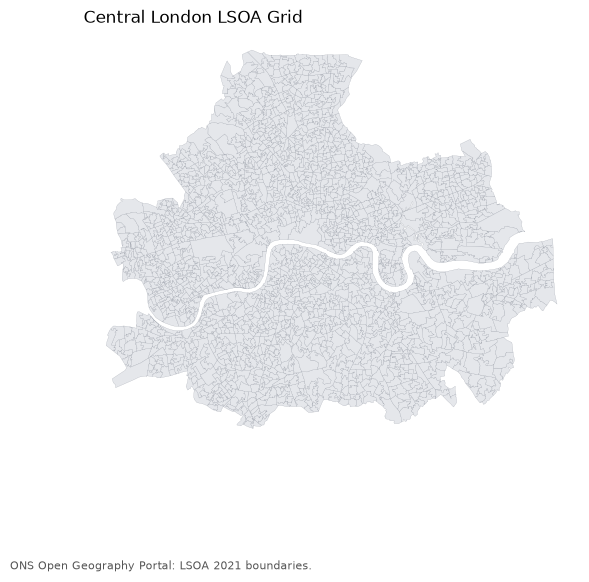

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 6.4))
areas.plot(ax=ax, facecolor="#e5e7eb", edgecolor="#6b7280", linewidth=0.10)
ax.set_title("Central London LSOA Grid", loc="left")
ax.set_axis_off()
cite(fig, "ONS Open Geography Portal: LSOA 2021 boundaries.")
plt.show()

hourly station flow implied by tfl taps and the rods hourly split.

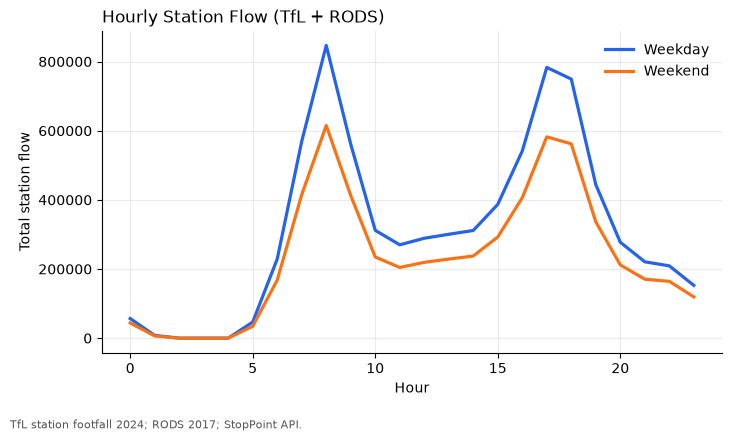

In [10]:
curves = {}
for daytype in ["weekday", "weekend"]:
    curves[daytype] = (stations[daytype].fillna(0).values[:, None] * stations[profile_cols].values).sum(axis=0)
fig, ax = plt.subplots()
ax.plot(hours, curves["weekday"], lw=2.3, label="Weekday", color="#2563eb")
ax.plot(hours, curves["weekend"], lw=2.3, label="Weekend", color="#f97316")
ax.set_title("Hourly Station Flow (TfL + RODS)", loc="left")
ax.set_xlabel("Hour"); ax.set_ylabel("Total station flow"); ax.legend(frameon=False)
cite(fig, "TfL station footfall 2024; RODS 2017; StopPoint API.")
plt.show()

segment share of footfall through the day (weekday), from concentration × hour profiles.

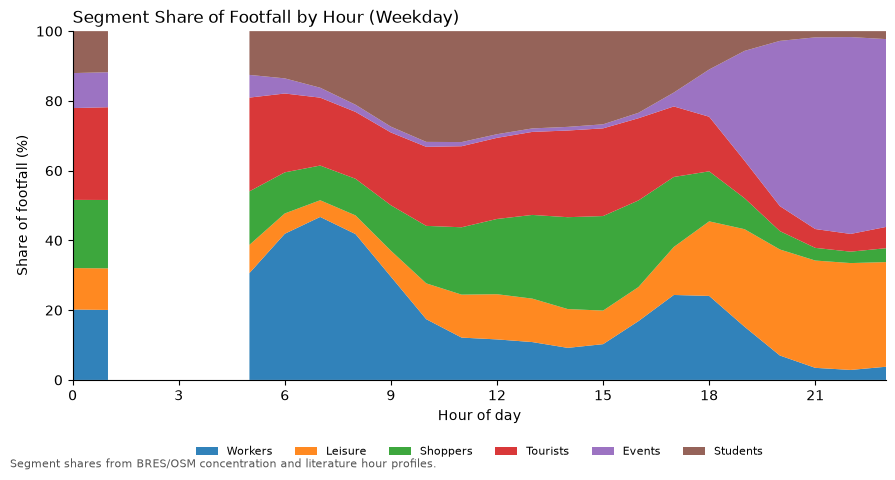

In [11]:
foot_by_hour = pd.DataFrame({s: [seg_foot["weekday"][s][:, hh].sum() for hh in hours] for s in segments}, index=hours)
shares = foot_by_hour.div(foot_by_hour.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.stackplot(hours, *[shares[s] for s in segments], labels=[s.title() for s in segments],
             colors=plt.cm.tab10.colors[:len(segments)], alpha=0.92)
ax.set_title("Segment Share of Footfall by Hour (Weekday)", loc="left")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Share of footfall (%)")
ax.set_xlim(0, 23); ax.set_ylim(0, 100); ax.set_xticks(range(0, 24, 3)); ax.grid(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=6, frameon=False, fontsize=8)
cite(fig, "Segment shares from BRES/OSM concentration and literature hour profiles.")
plt.tight_layout(); plt.show()

fixed base probability of giving per segment (from the literature).

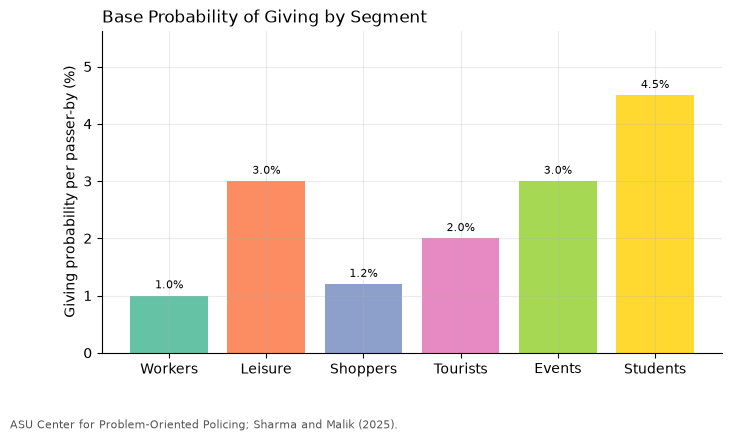

In [12]:
pg = pd.Series(p_give)
fig, ax = plt.subplots()
pct = pg * 100
bars = ax.bar(pct.index.str.title(), pct.values, color=plt.cm.Set2.colors[:6])
for b, raw in zip(bars, pg.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.08, f"{raw * 100:.1f}%", ha="center", va="bottom", fontsize=8)
ax.set_title("Base Probability of Giving by Segment", loc="left")
ax.set_ylabel("Giving probability per passer-by (%)"); ax.set_ylim(0, pct.max() * 1.25)
cite(fig, "ASU Center for Problem-Oriented Policing; Sharma and Malik (2025).")
plt.show()

base giving amount per segment, and ashe pay by sic section used to scale workers.

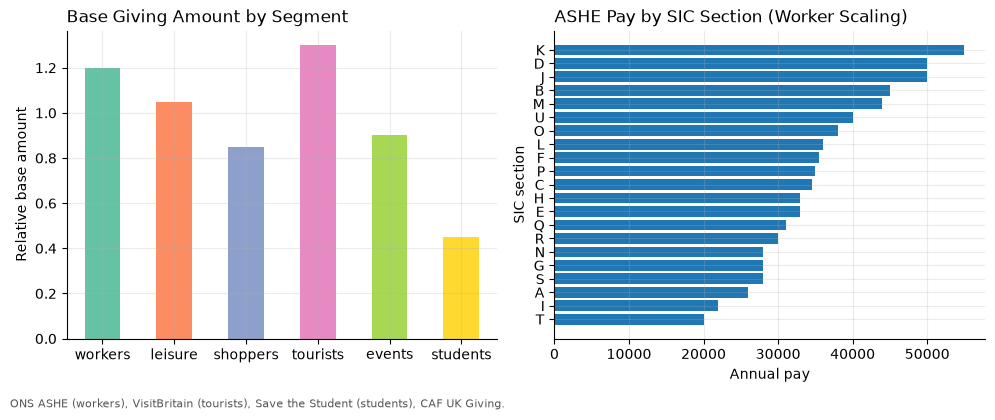

In [13]:
ab = pd.Series(a_base)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
ab.plot(kind="bar", ax=axes[0], color=plt.cm.Set2.colors[:6])
axes[0].set_title("Base Giving Amount by Segment", loc="left"); axes[0].set_ylabel("Relative base amount"); axes[0].tick_params(axis="x", rotation=0)
pay = ashe.sort_values("annual_pay")
axes[1].barh(pay["section"], pay["annual_pay"], color="#1f77b4")
axes[1].set_title("ASHE Pay by SIC Section (Worker Scaling)", loc="left"); axes[1].set_xlabel("Annual pay"); axes[1].set_ylabel("SIC section")
plt.tight_layout()
cite(fig, "ONS ASHE (workers), VisitBritain (tourists), Save the Student (students), CAF UK Giving.")
plt.show()

weather mood instrument by hour (normalised to median one).

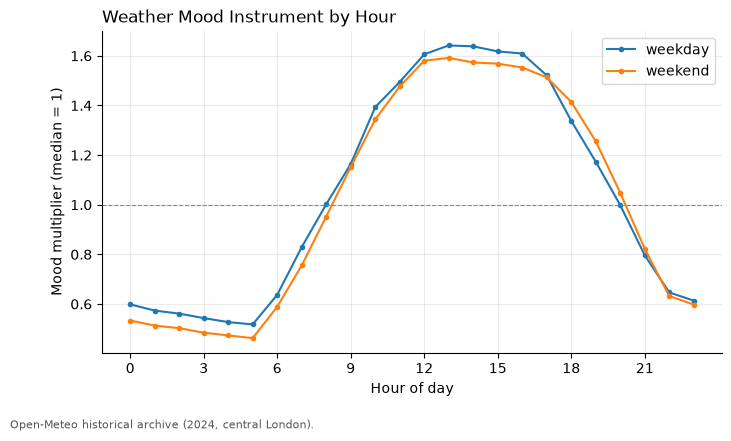

In [14]:
fig, ax = plt.subplots()
for d, c in [("weekday", "#1f77b4"), ("weekend", "#ff7f0e")]:
    ax.plot(hours, mood[d], marker="o", ms=3, label=d, color=c)
ax.axhline(1.0, color="#888888", lw=0.8, ls="--")
ax.set_title("Weather Mood Instrument by Hour", loc="left")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Mood multiplier (median = 1)"); ax.set_xticks(range(0, 24, 3)); ax.legend()
cite(fig, "Open-Meteo historical archive (2024, central London).")
plt.show()

competition pressure by borough (rough sleepers per unit of gross giving).

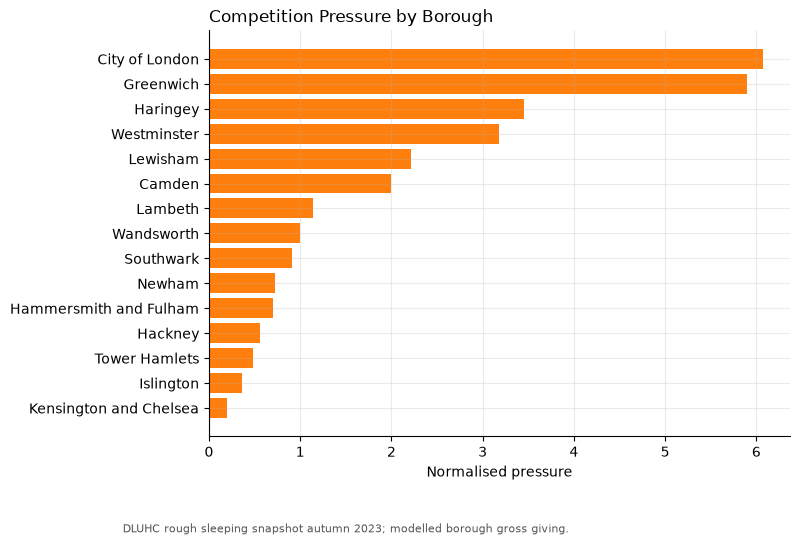

In [15]:
comp = surface[["borough", "competition_pressure"]].drop_duplicates().sort_values("competition_pressure")
fig, ax = plt.subplots(figsize=(7.5, 5.8))
ax.barh(comp["borough"], comp["competition_pressure"], color="#ff7f0e")
ax.set_title("Competition Pressure by Borough", loc="left"); ax.set_xlabel("Normalised pressure")
cite(fig, "DLUHC rough sleeping snapshot autumn 2023; modelled borough gross giving.")
plt.show()

gross giving pool across lsoas, weekday 12:00.

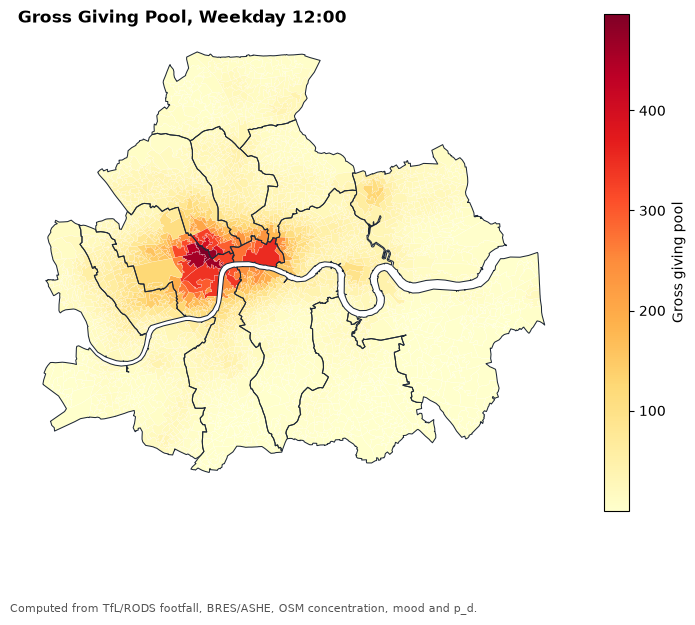

In [16]:
plot_g = surface.to_crs(crs_bng)
fig, ax = plt.subplots(figsize=(7.2, 7.2))
plot_g.plot(ax=ax, column="weekday_gross_h12", cmap="YlOrRd", linewidth=0.12, edgecolor="#ffffff",
            legend=True, legend_kwds={"shrink": 0.72, "label": "Gross giving pool"})
plot_g.dissolve("borough").boundary.plot(ax=ax, color="#1f2937", linewidth=0.75)
ax.set_title("Gross Giving Pool, Weekday 12:00", loc="left", fontweight="bold"); ax.set_axis_off()
cite(fig, "Computed from TfL/RODS footfall, BRES/ASHE, OSM concentration, mood and p_d.")
plt.tight_layout(); plt.show()

total lambda across central london by hour.

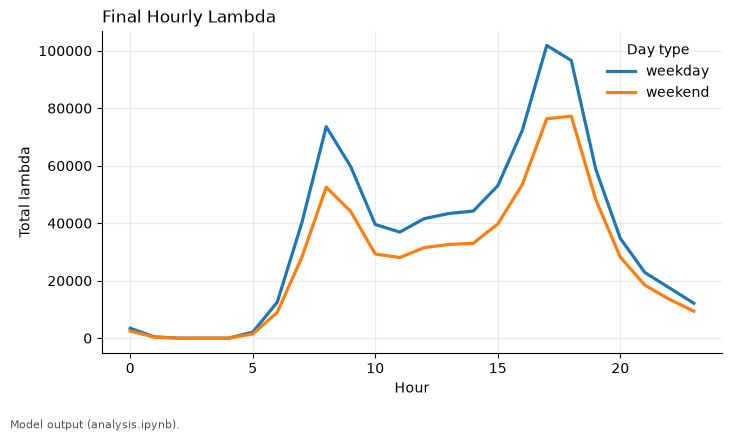

In [17]:
fig, ax = plt.subplots()
hourly_lambda.groupby(["hour", "daytype"])["lambda"].sum().unstack().plot(ax=ax, lw=2.3)
ax.set_title("Final Hourly Lambda", loc="left"); ax.set_xlabel("Hour"); ax.set_ylabel("Total lambda")
ax.legend(frameon=False, title="Day type")
cite(fig, "Model output (analysis.ipynb).")
plt.show()

weekday lambda surface by part of day.

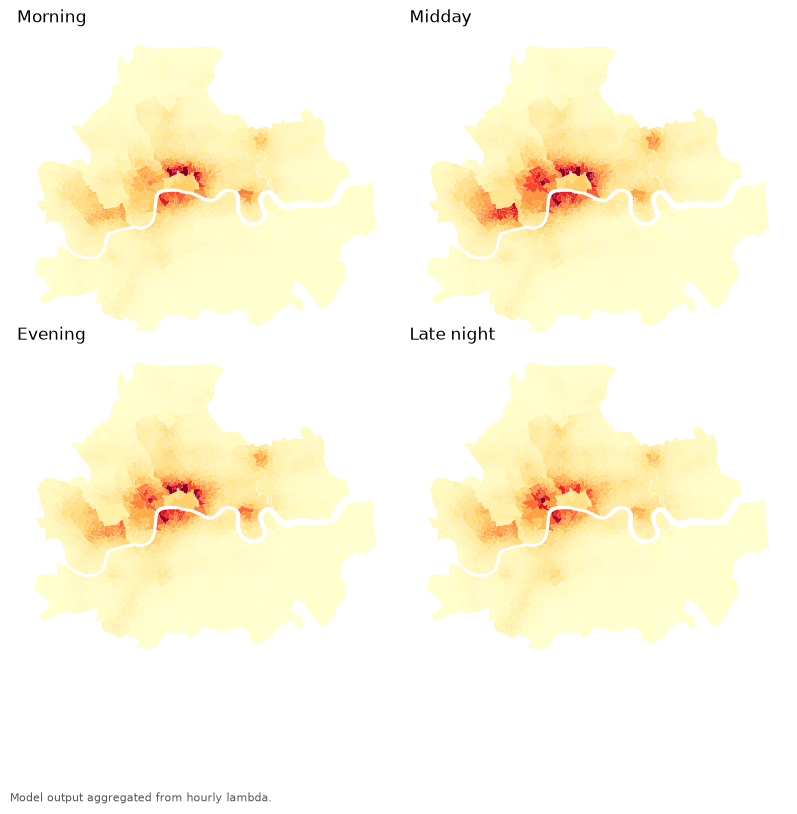

In [18]:
plot_g = surface.to_crs(crs_bng)
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
cols = ["weekday_morning", "weekday_midday", "weekday_evening", "weekday_late_night"]
titles = ["Morning", "Midday", "Evening", "Late night"]
for ax, col, title in zip(axes.ravel(), cols, titles):
    plot_g.plot(ax=ax, column=col, cmap="YlOrRd", linewidth=0.02, edgecolor="white")
    ax.set_title(title, loc="left"); ax.set_axis_off()
plt.tight_layout()
cite(fig, "Model output aggregated from hourly lambda.")
plt.show()

food access and the resulting nutrition-feasible area (>= 3 outlets within 400 m).

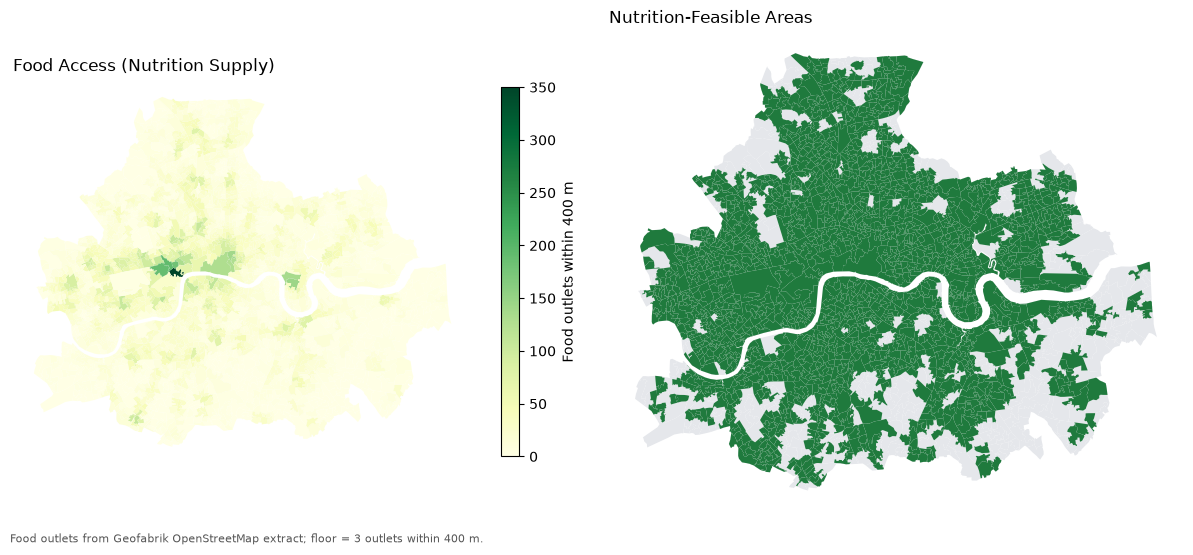

In [19]:
plot_g = surface.to_crs(crs_bng)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
plot_g.plot(ax=axes[0], column="food_outlets_400m", cmap="YlGn", linewidth=0.02, edgecolor="white",
            legend=True, legend_kwds={"shrink": 0.7, "label": "Food outlets within 400 m"})
axes[0].set_title("Food Access (Nutrition Supply)", loc="left"); axes[0].set_axis_off()
plot_g.plot(ax=axes[1], color="#e5e7eb", linewidth=0.02, edgecolor="white")
plot_g[plot_g["nutrition_feasible"] == 1].plot(ax=axes[1], color="#1f7a3d", linewidth=0.02, edgecolor="white")
axes[1].set_title("Nutrition-Feasible Areas", loc="left"); axes[1].set_axis_off()
cite(fig, "Food outlets from Geofabrik OpenStreetMap extract; floor = 3 outlets within 400 m.")
plt.tight_layout(); plt.show()

grocery proximity and the recommended surface (nutrition-feasible lambda x grocery proximity).

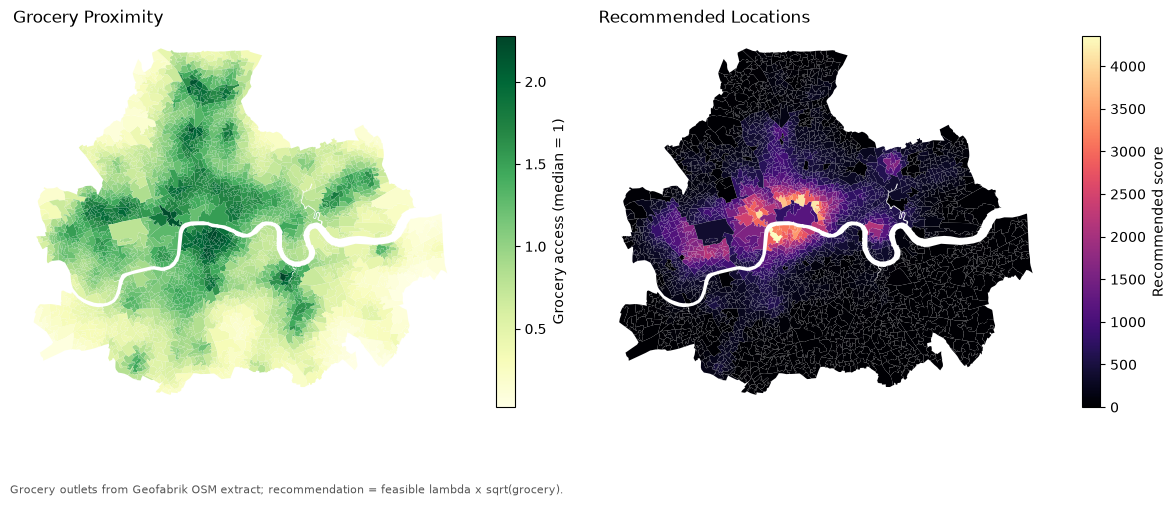

In [20]:
plot_g = surface.to_crs(crs_bng)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
plot_g.plot(ax=axes[0], column="grocery_access", cmap="YlGn", linewidth=0.02, edgecolor="white",
            legend=True, legend_kwds={"shrink": 0.7, "label": "Grocery access (median = 1)"})
axes[0].set_title("Grocery Proximity", loc="left"); axes[0].set_axis_off()
plot_g.plot(ax=axes[1], column="recommended_score", cmap="magma", linewidth=0.02, edgecolor="white",
            legend=True, legend_kwds={"shrink": 0.7, "label": "Recommended score"})
axes[1].set_title("Recommended Locations", loc="left"); axes[1].set_axis_off()
cite(fig, "Grocery outlets from Geofabrik OSM extract; recommendation = feasible lambda x sqrt(grocery).")
plt.tight_layout(); plt.show()

food-bank points and distance to the nearest one.

/Users/siddharthgianchandani/street-giving-london/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


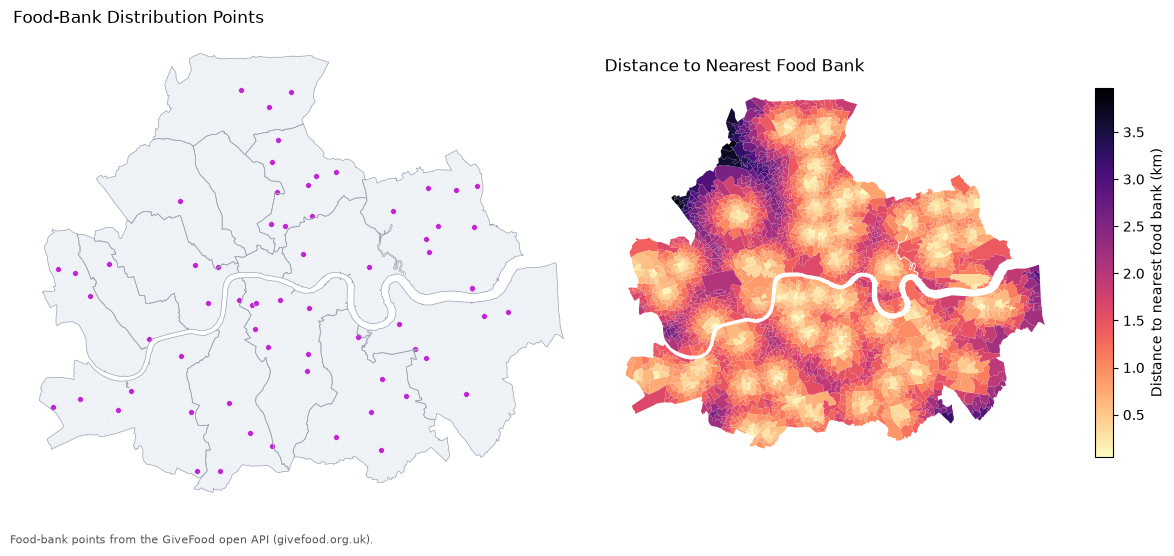

In [21]:
plot_g = surface.to_crs(crs_bng)
fb = food_banks.to_crs(crs_bng)
cent = plot_g.copy(); cent["geometry"] = cent.representative_point()
near = gpd.sjoin_nearest(cent, fb[["geometry"]], distance_col="fb_dist_m")
near = near[~near.index.duplicated()]
plot_g = plot_g.assign(fb_dist_km=near["fb_dist_m"].values / 1000)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
plot_g.plot(ax=axes[0], color="#eef2f7", linewidth=0.02, edgecolor="white")
plot_g.dissolve("borough").boundary.plot(ax=axes[0], color="#9aa3af", linewidth=0.5)
fb.plot(ax=axes[0], color="#c026d3", markersize=18, edgecolor="white", linewidth=0.4)
axes[0].set_title("Food-Bank Distribution Points", loc="left"); axes[0].set_axis_off()
plot_g.plot(ax=axes[1], column="fb_dist_km", cmap="magma_r", linewidth=0.02, edgecolor="white",
            legend=True, legend_kwds={"shrink": 0.7, "label": "Distance to nearest food bank (km)"})
axes[1].set_title("Distance to Nearest Food Bank", loc="left"); axes[1].set_axis_off()
cite(fig, "Food-bank points from the GiveFood open API (givefood.org.uk).")
plt.tight_layout(); plt.show()

highest-lambda lsoa at each hour (the literal surface maximum, not a recommendation).

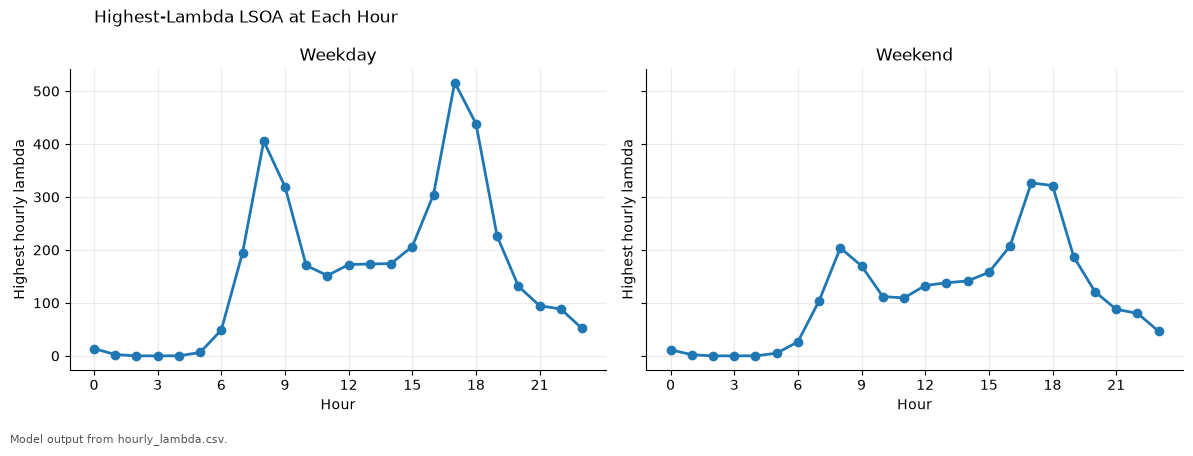

,daytype,hour,msoa_name,borough,lambda
1848,weekday,0,Camden 028D,Camden,13.8
1849,weekday,1,Camden 028D,Camden,2.4
2,weekday,2,City of London 001A,City of London,0.0
3,weekday,3,City of London 001A,City of London,0.0
4,weekday,4,City of London 001A,City of London,0.0
15149,weekday,5,Islington 023D,Islington,6.3
15150,weekday,6,Islington 023D,Islington,48.9
15151,weekday,7,Islington 023D,Islington,194.6
15152,weekday,8,Islington 023D,Islington,405.5
15609,weekday,9,Islington 022D,Islington,319.5


In [22]:
best = hourly_lambda.loc[hourly_lambda.groupby(["daytype", "hour"])["lambda"].idxmax()].sort_values(["daytype", "hour"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, daytype in zip(axes, ["weekday", "weekend"]):
    sub = best[best["daytype"] == daytype]
    ax.plot(sub["hour"], sub["lambda"], marker="o", lw=2)
    ax.set_title(daytype.title()); ax.set_xlabel("Hour"); ax.set_ylabel("Highest hourly lambda"); ax.set_xticks(range(0, 24, 3))
plt.suptitle("Highest-Lambda LSOA at Each Hour", x=0.08, ha="left", fontsize=12)
plt.tight_layout()
cite(fig, "Model output from hourly_lambda.csv.")
plt.show()
best[["daytype", "hour", "msoa_name", "borough", "lambda"]].assign(**{"lambda": best["lambda"].round(1)})